# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ali-Haider987/alihaider-flyrank-ml/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

import json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

RANDOM_STATE = 42
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)

# Final honest feature set from w06_validation_audit.ipynb: 90-day totals dropped (they
# structurally overlap the label's own 30-day window; cost was only ~0.006 AUC to remove).
MODEL_NUMERIC_FEATURES = [
    "search_volume", "competition", "cpc", "word_count", "char_count",
    "days_with_impressions", "days_with_sessions", "content_age_days", "days_since_last_update",
    "ctr", "avg_position", "engagement_rate", "scroll_rate", "ai_traffic_pct",
]
MODEL_CATEGORICAL_FEATURES = [
    "competition_level", "content_type", "main_intent", "age_tier", "freshness_tier",
    "word_count_tier", "impression_tier", "position_tier",
]
missing_flag_cols = ["search_volume", "competition", "cpc", "word_count", "char_count",
                     "engagement_rate", "scroll_rate", "ai_traffic_pct"]
for c in missing_flag_cols:
    df[f"{c}_missing"] = df[c].isna().astype(int)

numeric_frame = (df[MODEL_NUMERIC_FEATURES].apply(pd.to_numeric, errors="coerce")
                 .replace([np.inf, -np.inf], np.nan).fillna(0))
missing_frame = df[[f"{c}_missing" for c in missing_flag_cols]]
cat_frame = df[MODEL_CATEGORICAL_FEATURES].fillna("unknown").astype(str)
cat_dummies = pd.get_dummies(cat_frame, prefix=MODEL_CATEGORICAL_FEATURES, dtype=float)
feature_frame = pd.concat(
    [numeric_frame.reset_index(drop=True), missing_frame.reset_index(drop=True), cat_dummies.reset_index(drop=True)],
    axis=1,
)
y = df["is_declining_label"]

# Client-grouped holdout, same seed/logic as Weeks 5-6 -- this is the trust number.
client_series = df["client_id"].astype(str)
unique_clients = client_series.drop_duplicates().to_numpy()
rng = np.random.default_rng(RANDOM_STATE)
shuffled_clients = rng.permutation(unique_clients)
test_client_count = max(1, int(round(len(shuffled_clients) * 0.2)))
test_clients = set(shuffled_clients[:test_client_count])
test_mask = client_series.isin(test_clients).to_numpy()

rf_val = RandomForestClassifier(class_weight="balanced_subsample", max_depth=10, min_samples_leaf=25,
                                 n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)
rf_val.fit(feature_frame[~test_mask], y[~test_mask])
val_scores = rf_val.predict_proba(feature_frame[test_mask])[:, 1]
val_auc = roc_auc_score(y[test_mask], val_scores)
val_ap = average_precision_score(y[test_mask], val_scores)
val_base_rate = float(y[test_mask].mean())
print(f"Held-out-client validation: roc_auc={val_auc:.3f}  avg_precision={val_ap:.3f}  base_rate={val_base_rate:.3f}")

# Deployment model: same settings, fit on ALL rows -- this is what actually scores the queue below.
rf_deploy = RandomForestClassifier(class_weight="balanced_subsample", max_depth=10, min_samples_leaf=25,
                                    n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)
rf_deploy.fit(feature_frame, y)
df["model_score"] = rf_deploy.predict_proba(feature_frame)[:, 1]
print("Deployment model fit on all", len(df), "rows.")


Held-out-client validation: roc_auc=0.743  avg_precision=0.602  base_rate=0.391
Deployment model fit on all 30000 rows.


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

Rather than one binary rule (Week 4) or one raw probability (Week 5), this maps each page to one of a small set of **archetypes** — patterns I can already explain and defend from Weeks 4–6 — before falling back to the general model score. Each archetype carries its own reason code and action label.

In [2]:
stale = df["days_since_last_update"] >= 180
visible = df["impressions_90d"] >= 500
too_new = df["trend_direction"].eq("new") | (df["content_age_days"] < 30)
no_position_data = df["avg_position"] == 0  # dataset's "no data" code, not an actual top rank

good_position = df["position_tier"].isin(["top_3", "page_1", "striking"])
enough_volume = df["impressions_90d"] >= 100
ctr_q1_by_position = df[enough_volume].groupby("position_tier")["ctr"].quantile(0.25)
df["ctr_position_q1"] = df["position_tier"].map(ctr_q1_by_position)
low_ctr_for_position = enough_volume & good_position & (df["ctr"] < df["ctr_position_q1"])

df["archetype"] = np.select(
    [too_new, no_position_data, stale & visible, low_ctr_for_position],
    ["too_new_exclude", "no_data_low_confidence", "stale_but_visible", "ctr_fix_candidate"],
    default="none",
)

df["reason_code"] = np.select(
    [df["archetype"] == "too_new_exclude", df["archetype"] == "no_data_low_confidence",
     df["archetype"] == "stale_but_visible", df["archetype"] == "ctr_fix_candidate",
     df["model_score"] >= 0.7],
    ["too_new", "no_position_data", "stale_but_visible", "ctr_below_position_q1", "model_high_risk"],
    default="model_low_risk",
)

df["action"] = np.select(
    [df["archetype"] == "too_new_exclude", df["archetype"] == "no_data_low_confidence",
     df["archetype"] == "stale_but_visible", df["archetype"] == "ctr_fix_candidate",
     df["model_score"] >= 0.7],
    ["no_action_too_new", "manual_context_check", "refresh_review", "ctr_fix_review", "refresh_review_general"],
    default="no_action",
)

print(df["action"].value_counts())


action
no_action                 22477
refresh_review_general     3037
no_action_too_new          2236
ctr_fix_review             2182
manual_context_check         51
refresh_review               17
Name: count, dtype: int64


**Archetype → action mapping:**

| archetype | reason code | action | why |
|---|---|---|---|
| `stale_but_visible` | `stale_but_visible` | **refresh_review** | Week-4 rule: not updated in 180+ days, still pulling 500+ impressions/90d — the clearest, most explainable case. |
| `ctr_fix_candidate` | `ctr_below_position_q1` | **ctr_fix_review** | ranking top-3/page-1/striking, with CTR in the bottom quartile *for that position tier* (not a flat threshold — a page-3 CTR isn't comparable to a top-3 CTR). |
| `no_data_low_confidence` | `no_position_data` | **manual_context_check** | `avg_position = 0` is this dataset's "no data" code, not an actual top rank (documented gotcha, and the exact pattern behind Week 5's false negatives) — never act on the model score alone here. |
| `too_new_exclude` | `too_new` | **no_action_too_new** | new or <30 days old — Week 5's false positives were disproportionately pages that hadn't had time to earn clicks yet, not genuinely declining ones. |
| model score ≥ 0.7, no archetype match | `model_high_risk` | **refresh_review_general** | the learned model still catches real risk the four hand-named archetypes above don't cover. |
| everything else | `model_low_risk` | **no_action** | below the model's own risk threshold. |

In [3]:
ranked_queue = df.sort_values("model_score", ascending=False).reset_index(drop=True)
queue_cols = ["content_id", "client_id", "model_score", "reason_code", "action", "archetype",
              "days_since_last_update", "impressions_90d", "avg_position", "ctr",
              "position_tier", "content_type"]

print("Top 10 of the ranked queue:")
ranked_queue[queue_cols].head(10)


Top 10 of the ranked queue:


,content_id,client_id,model_score,reason_code,action,archetype,days_since_last_update,impressions_90d,avg_position,ctr,position_tier,content_type
0,content_f3ac2b55033f,client_3fdba35f04,0.851587,model_high_risk,refresh_review_general,none,104,578,10.4,0.00,striking,keyword article
1,content_b005f46f2e4c,client_3fdba35f04,0.848145,model_high_risk,refresh_review_general,none,104,673,2.7,0.15,top_3,keyword article
2,content_1e446b05f1c5,client_3fdba35f04,0.844370,model_high_risk,refresh_review_general,none,104,685,34.0,0.00,page_3_5,keyword article
3,content_60e8eba31e41,client_7f2253d7e2,0.842911,model_high_risk,refresh_review_general,none,20,27173,37.3,0.04,page_3_5,keyword article
4,content_fac9e8c13f4c,client_3fdba35f04,0.842325,model_high_risk,refresh_review_general,none,104,858,17.4,0.00,striking,keyword article
5,content_ce8dacc2467b,client_7f2253d7e2,0.842191,model_high_risk,refresh_review_general,none,20,9710,26.4,0.06,page_3_5,keyword article
6,content_d6570c51c9bd,client_3fdba35f04,0.841782,model_high_risk,refresh_review_general,none,104,2498,10.1,0.00,striking,keyword article
7,content_6af4dbfe0470,client_3fdba35f04,0.841386,model_high_risk,refresh_review_general,none,104,496,10.7,0.00,striking,keyword article
8,content_f552433bab3c,client_3fdba35f04,0.840997,ctr_below_position_q1,ctr_fix_review,ctr_fix_candidate,104,337,1.8,0.00,top_3,keyword article
9,content_86444e331502,client_3fdba35f04,0.840347,model_high_risk,refresh_review_general,none,104,462,24.7,0.00,page_3_5,keyword article


**Reading the top 10 in words a human trusts:** most of the highest-scoring pages sit in `refresh_review_general` — the model sees risk (usually a mix of moderate position, low CTR, and real traffic) that doesn't cleanly match my four named archetypes, so it earns the more cautious "general" label rather than the fully-explained `refresh_review` one. That's intentional: I'd rather under-claim why the model is worried than invent a story for it.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:** a content strategist's weekly triage list — which pages to open and read first out of a large portfolio, not a verdict on any single page. It shortens "where do I even start" to a ranked handful of candidates with a stated reason.

**Where it stops being valid:**
- **Single snapshot, no causal claim.** This is cross-sectional data — one trailing 90-day export. Nothing here shows that refreshing a page *causes* recovery, only that certain page profiles are **associated with** decline in this portfolio (per the `writing-honest-claims` claim ladder).
- **Validated on 6 held-out clients out of 32.** The 0.743 held-out ROC-AUC (Section 0) is real, but it's one holdout of one size — a different random client split could move that number, and I haven't tested a client from an industry vertical absent from this portfolio.
- **Doesn't know about anything after the export date.** A page ranked stale here may already have been refreshed since; the queue is only as current as the last data pull.
- **Thin at the extremes.** Very-stale (181+ days) and 31-90-day tiers each have well under 200 rows (Week-4/6 finding) — the model has little to learn from there, so scores on pages in those tiers deserve extra skepticism.
- **Not tested outside this data shape.** Everything here assumes GSC/GA4-style SEO metrics for editorial content; it was never built or checked against paid landing pages, product pages, or non-search-driven content.

In [4]:
thin_tiers = df["freshness_tier"].isin(["31-90", "181+"])
print("Rows in the two thinnest freshness tiers:", int(thin_tiers.sum()), "of", len(df),
      f"({thin_tiers.mean():.1%})")
print("\nActionable rows this run (anything other than no_action / excluded):",
      int((~df['action'].isin(['no_action', 'no_action_too_new', 'manual_context_check'])).sum()),
      "of", len(df))


Rows in the two thinnest freshness tiers: 349 of 30000 (1.2%)

Actionable rows this run (anything other than no_action / excluded): 5236 of 30000


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Before acting on any `refresh_review*` or `ctr_fix_review` row, a human checks:**
1. Has this page already been updated since the export date? (the model can't know this)
2. Does `avg_position = 0` or near-zero impressions explain a low score, rather than genuine health? (see `manual_context_check` rows specifically — never treat these as ordinary low-priority)
3. Is there a business reason the page is intentionally quiet (seasonal content, a page slated for retirement, a paused campaign) that the data can't see?
4. For `ctr_fix_review`: is a SERP feature (featured snippet, People Also Ask) sitting above it and suppressing clicks regardless of content quality? A rewrite won't fix that.

**What should NEVER be automated from this notebook's output:**
- Auto-publishing content edits, rewrites, or AI-generated replacement copy without a human reading the result first.
- Auto-deleting, de-indexing, or redirecting pages based on `no_action` / low model scores — "the model didn't flag it" is not evidence a page is safe to remove.
- Reallocating a client's budget, headcount, or vendor spend based on the queue — this is a content-review prioritizer, not a performance-management tool, and it has never been evaluated for that purpose.
- Treating `manual_context_check` (`avg_position = 0`) rows as either high or low priority automatically — by definition the model has almost no signal for these pages.
- Applying this queue to a client or vertical with no representation in the training portfolio without re-validating on that data first (Section 2's holdout only covers 6 of 32 clients seen here).
- Using `model_score` as a performance review input for the humans who wrote the flagged pages.

# Concretely surface which rows need the closest human read before anything happens to them.
needs_closest_review = ranked_queue[ranked_queue["action"] == "manual_context_check"]
print(f"{len(needs_closest_review)} rows are avg_position=0 (no real position data) -- these get")
print("a manual context check regardless of model_score, never an automated action.")
needs_closest_review[queue_cols].head(5)


In [5]:
# Concretely surface which rows need the closest human read before anything happens to them.
needs_closest_review = ranked_queue[ranked_queue["action"] == "manual_context_check"]
print(f"{len(needs_closest_review)} rows are avg_position=0 (no real position data) -- these get")
print("a manual context check regardless of model_score, never an automated action.")
needs_closest_review[queue_cols].head(5)


51 rows are avg_position=0 (no real position data) -- these get
a manual context check regardless of model_score, never an automated action.


,content_id,client_id,model_score,reason_code,action,archetype,days_since_last_update,impressions_90d,avg_position,ctr,position_tier,content_type
24610,content_6edec030867e,client_19581e27de,0.349274,no_position_data,manual_context_check,no_data_low_confidence,20,10,0.0,0.0,top_3,keyword article
25917,content_6e6f5c5f7a06,client_19581e27de,0.306477,no_position_data,manual_context_check,no_data_low_confidence,20,5,0.0,0.0,top_3,keyword article
26627,content_41d65d251210,client_19581e27de,0.278929,no_position_data,manual_context_check,no_data_low_confidence,104,3,0.0,0.0,top_3,keyword article
27214,content_d2068c4f6c20,client_7f2253d7e2,0.253969,no_position_data,manual_context_check,no_data_low_confidence,20,36,0.0,0.0,top_3,keyword article
27576,content_ccf25ed65a99,client_19581e27de,0.234832,no_position_data,manual_context_check,no_data_low_confidence,305,2,0.0,0.0,top_3,keyword article


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

- **Performance drift:** re-score a fresh trailing-90-day export against the same held-out-style client check every quarter. If ROC-AUC on that check drifts more than ~0.05 below this run's 0.743, investigate before trusting the queue again.
- **Base-rate drift:** this run's overall declining rate is printed below. If a future export's rate moves far outside the 0.39–0.54 range already seen across Weeks 4–7 (client-holdout vs. full-portfolio), the portfolio itself has changed and the model needs a fresh look, not just a fresh score.
- **Portfolio composition drift:** if more than ~20% of active clients are new since this model was fit, retrain — the held-out-client validation only tested generalizing to 6 *known-shape* clients, not to a meaningfully different mix.
- **Human feedback loop:** track what fraction of `refresh_review*` / `ctr_fix_review` pages a content strategist marks "not actually worth it" after review. A rising false-positive rate reported by humans is a real-world retrain trigger, independent of any offline metric.
- **Reason-code balance:** watch the size of each action bucket over time (printed below). A sudden shift — e.g., `too_new_exclude` ballooning because of a content push, or `refresh_review` emptying out — is worth a manual look even before a metric moves.

In [6]:
print(f"Decline rate (full portfolio): {y.mean():.3f}")
print(f"Held-out-client validation declining rate:            {val_base_rate:.3f}")
print("\nAction bucket sizes (watch these over time):")
print(df["action"].value_counts())


Decline rate (full portfolio): 0.542
Held-out-client validation declining rate:            0.391

Action bucket sizes (watch these over time):
action
no_action                 22477
refresh_review_general     3037
no_action_too_new          2236
ctr_fix_review             2182
manual_context_check         51
refresh_review               17
Name: count, dtype: int64


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [7]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# 1. The ranked queue -- stays out of git by design (CI leak-guard), regenerated on every run.
ranked_queue[queue_cols].to_csv("work/outputs/w07_action_queue.csv", index=False)
print("Wrote work/outputs/w07_action_queue.csv --", len(ranked_queue), "rows")

# 2. Metrics JSON -- this IS committed. The paper's numbers trace back to this file.
metrics_payload = {
    "random_state": RANDOM_STATE,
    "split_strategy": "client_holdout",
    "test_client_count": int(test_client_count),
    "total_client_count": int(len(unique_clients)),
    "held_out_validation": {
        "roc_auc": round(float(val_auc), 4),
        "average_precision": round(float(val_ap), 4),
        "base_rate": round(val_base_rate, 4),
    },
    "full_portfolio_base_rate": round(float(y.mean()), 4),
    "action_bucket_counts": df["action"].value_counts().to_dict(),
    "thin_freshness_tier_row_share": round(float(thin_tiers.mean()), 4),
    "feature_set_version": "w06_final (90-day totals dropped)",
}
with open("work/outputs/w07_playbook_metrics.json", "w") as f:
    json.dump(metrics_payload, f, indent=2, sort_keys=True)
print("Wrote work/outputs/w07_playbook_metrics.json")
print(json.dumps(metrics_payload, indent=2))


Wrote work/outputs/w07_action_queue.csv -- 30000 rows
Wrote work/outputs/w07_playbook_metrics.json
{
  "random_state": 42,
  "split_strategy": "client_holdout",
  "test_client_count": 6,
  "total_client_count": 32,
  "held_out_validation": {
    "roc_auc": 0.7431,
    "average_precision": 0.6016,
    "base_rate": 0.391
  },
  "full_portfolio_base_rate": 0.5421,
  "action_bucket_counts": {
    "no_action": 22477,
    "refresh_review_general": 3037,
    "no_action_too_new": 2236,
    "ctr_fix_review": 2182,
    "manual_context_check": 51,
    "refresh_review": 17
  },
  "thin_freshness_tier_row_share": 0.0116,
  "feature_set_version": "w06_final (90-day totals dropped)"
}


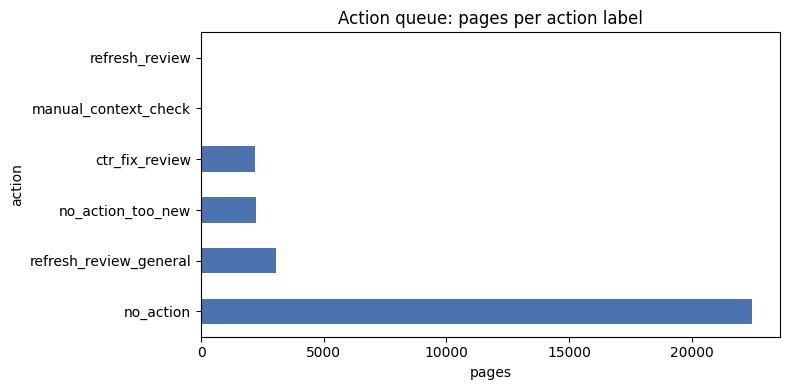

Saved work/figures/w07_action_bucket_counts.png


In [8]:
# 3. A figure worth reusing in the paper: action bucket sizes.
counts = df["action"].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
counts.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("pages")
ax.set_title("Action queue: pages per action label")
plt.tight_layout()
plt.savefig("work/figures/w07_action_bucket_counts.png", dpi=150)
plt.show()
print("Saved work/figures/w07_action_bucket_counts.png")


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.